# Personal Least Squares Method

In [62]:
import numpy as np
#personal least squares method
def leastsquares(x, y):
    #define all variables
    sumX = sum(x)
    sumX2 = sum(x**2)
    sumY = sum(y)
    sumXY = sum(x*y)
    #calculate m and c based off of the algorithms provided
    m = (len(x) * sumXY - sumX * sumY) / (len(x) * sumX2 - (sumX**2))
    c = (sumY - m * sumX) / len(x)
    return m, c
    
        

Slope: -0.17188899717493297, Intercept: 0.6123835178798751


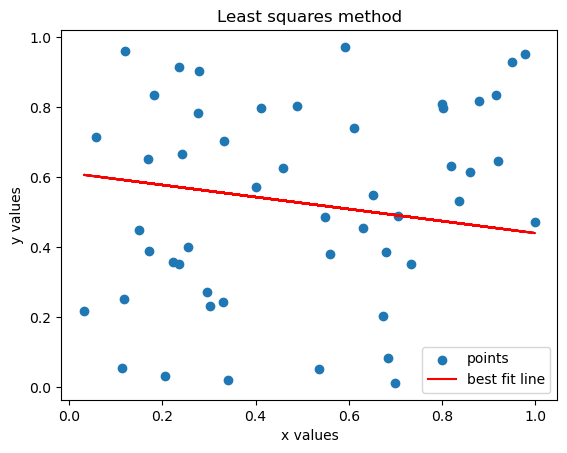

In [63]:
import random
import matplotlib.pyplot as plt
#generated random x and y vectors and calculated the m and c of the best fit line
x = np.random.rand(50)
y = np.random.rand(50)
x_sorted = np.sort(x)
m, c = leastsquares(x_sorted, y)
print(f"Slope: {m}, Intercept: {c}")

#plotted random points and the best fit line
plt.scatter(x, y,label="points")
yb = m*x + c
plt.plot(x, yb)
plt.plot(x, yb, 'r', label="best fit line")
plt.title("Least squares method")
plt.legend()
plt.xlabel("x values")
plt.ylabel("y values")
plt.show()

In [64]:
#generate a linear function with a random slope between -5 and 5 and a random intercept between -10 and 10
x = np.arange(0, 1.01, 0.01)
m = np.random.uniform(-5, 5)
b= np.random.uniform(-10, 10)
y = m*x + b
#introduce error between -1 and 1 (abs 0 and 1)
noise = np.random.uniform(-1, 1, len(x))
y += noise

In [65]:
#calculate m and c using my least squares function
mfit, cfit = leastsquares(x, y)
print(f"Slope: {mfit}, Intercept: {cfit}")

Slope: -3.3732014231118153, Intercept: -8.762601041831394


In [66]:
#calculate and find the largest and smallest residuals and their locations in the array
residuals = np.abs(y - (mfit*x + b))
print(f"Largest residual is {max(residuals)} at {x[np.argmin(residuals)]}, Smallest Residual is {min(residuals)} at {x[np.argmax(residuals)]}")

Largest residual is 1.1426459030799379 at 0.81, Smallest Residual is 0.0025525144783031806 at 0.8200000000000001


In [67]:
#calculate the best fit line using the numpy method 
A = np.vstack([x, np.ones(len(x))]).T
mNumpy, cNumpy = np.linalg.lstsq(A, y, rcond=None)[0]
print(f"Slope: {mNumpy}, Intercept: {cNumpy}")

Slope: -3.373201423111773, Intercept: -8.762601041831417


# the least square method that I coded and the numpy version match exactly.

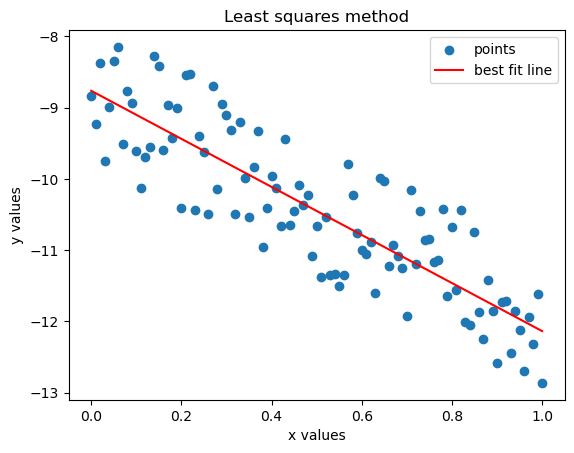

In [68]:
#plot the best fit line using my function and the random points 
plt.scatter(x, y, label="points")
yb = mfit*x + cfit
plt.plot(x, yb, 'r', label="best fit line")
plt.legend()
plt.title("Least squares method")
plt.xlabel("x values")
plt.ylabel("y values")
plt.show()

# I used Gemini to help me find a function that can locate the array index that contains a certain value to find the min and max residual locations in the array. Other than that, no AI was used.